# Prediccion de Tarjeta de Credito - Universal Bank
### Fundamentos de Aprendizaje de Maquina

**Variable objetivo:** `tarjeta de credito` (0 = no tiene, 1 = tiene) → **Clasificacion binaria**

**Modelos:** kNN y Regresion Logistica

---
## 0. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
SEED = 42

---
## 1. Carga y EDA

In [2]:
df = pd.read_excel('UniversalBankMODIFIEDcl.xlsx')
# Eliminar columnas que no son predictores (ID, Postal son identificadores)
df = df.drop(columns=['ID', 'Postal'])
print(f'Dimensiones: {df.shape}')
print(f'Nulos: {df.isnull().sum().sum()}')
df.head()

Dimensiones: (4501, 12)
Nulos: 0


,Edad,Experiencia,Ingreso,Familia,credito,educacion,hipoteca,credito rotativo,cuenta de ahorros,CDT,servicios inline,tarjeta de credito
0,61,36,128,1,2.6,1,0,0,0,0,1,0
1,29,3,113,2,0.2,1,0,0,0,0,1,1
2,29,0,134,4,6.5,3,0,1,0,0,0,0
3,48,23,19,1,0.1,1,0,0,0,0,1,0
4,65,39,35,1,0.5,3,0,0,0,0,0,0


Distribucion de tarjeta de credito:
tarjeta de credito
0    3188
1    1313
Name: count, dtype: int64

Porcentaje clase 1 (tiene tarjeta): 29.2%
Porcentaje clase 0 (no tiene):      70.8%


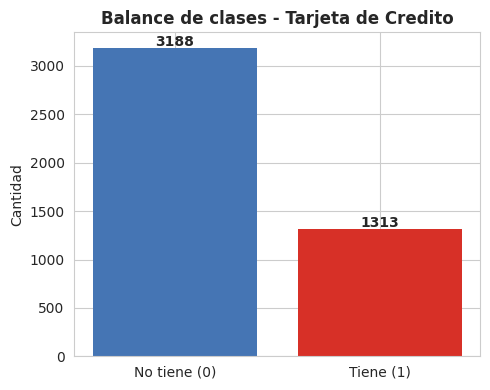

In [3]:
# Distribucion del target
vc = df['tarjeta de credito'].value_counts()
print('Distribucion de tarjeta de credito:')
print(vc)
print(f'\nPorcentaje clase 1 (tiene tarjeta): {vc[1]/len(df)*100:.1f}%')
print(f'Porcentaje clase 0 (no tiene):      {vc[0]/len(df)*100:.1f}%')

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.bar(['No tiene (0)', 'Tiene (1)'], [vc[0], vc[1]], color=['#4575b4','#d73027'], edgecolor='none')
ax.set_title('Balance de clases - Tarjeta de Credito', fontweight='bold')
ax.set_ylabel('Cantidad')
for i, v in enumerate([vc[0], vc[1]]):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_balance_clases.png', dpi=120, bbox_inches='tight')
plt.show()

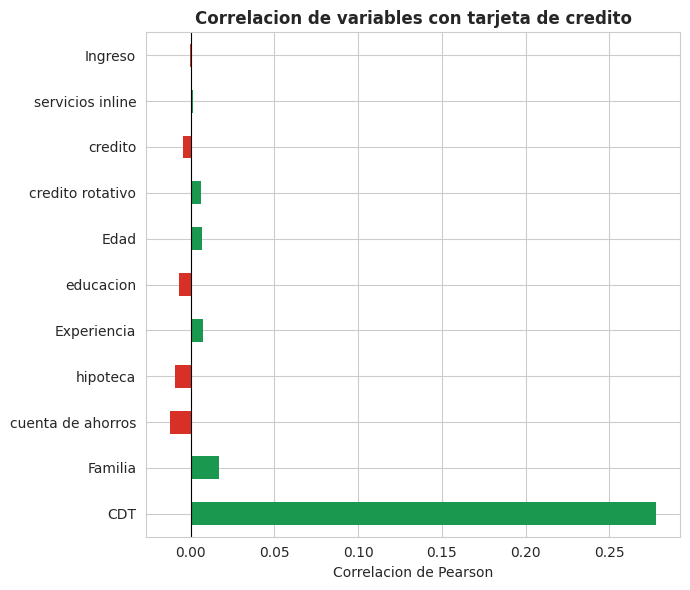

CDT                  0.277730
Familia              0.016785
cuenta de ahorros   -0.012033
hipoteca            -0.009528
Experiencia          0.007380
educacion           -0.007125
Edad                 0.006933
credito rotativo     0.006229
credito             -0.004634
servicios inline     0.001703
Ingreso             -0.000385


In [4]:
# Correlacion de variables con el target
corr = df.corr()['tarjeta de credito'].drop('tarjeta de credito').sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#1a9850' if x > 0 else '#d73027' for x in corr]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlacion de variables con tarjeta de credito', fontweight='bold')
ax.set_xlabel('Correlacion de Pearson')
plt.tight_layout()
plt.savefig('fig2_correlaciones.png', dpi=120, bbox_inches='tight')
plt.show()
print(corr.to_string())

---
## 2. Preparacion de Datos

In [5]:
feature_cols = [c for c in df.columns if c != 'tarjeta de credito']
X = df[feature_cols]
y = df['tarjeta de credito']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Clase 1 en train: {y_train.mean()*100:.1f}% | en test: {y_test.mean()*100:.1f}%')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 3600 | Test: 901
Clase 1 en train: 29.2% | en test: 29.2%


---
## 3. kNN - Busqueda del k optimo

k optimo (max accuracy CV): k=26 -> CV Accuracy=0.7461


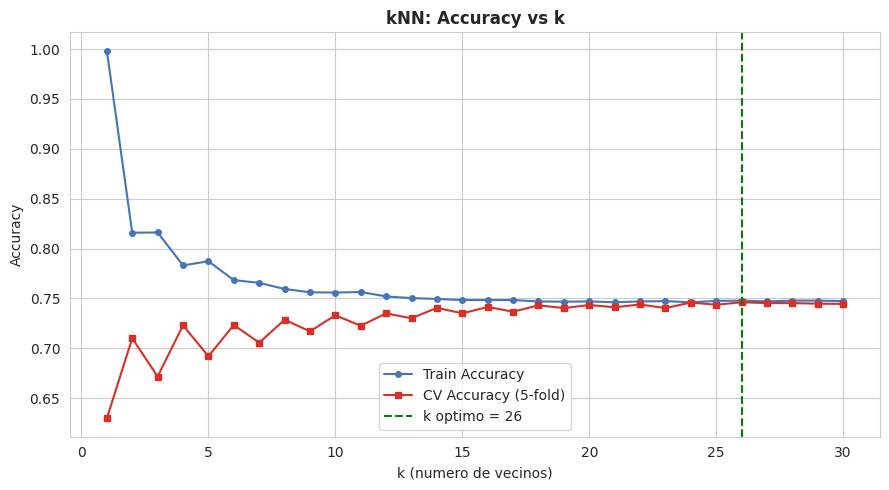

In [6]:
# Probar k de 1 a 30 con CV
k_range = range(1, 31)
cv_scores = []
train_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_acc = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy').mean()
    knn.fit(X_train_sc, y_train)
    train_acc = accuracy_score(y_train, knn.predict(X_train_sc))
    cv_scores.append(cv_acc)
    train_scores.append(train_acc)

k_optimo = k_range[np.argmax(cv_scores)]
print(f'k optimo (max accuracy CV): k={k_optimo} -> CV Accuracy={max(cv_scores):.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), train_scores, 'o-', label='Train Accuracy', color='#4575b4', markersize=4)
ax.plot(list(k_range), cv_scores, 's-', label='CV Accuracy (5-fold)', color='#d73027', markersize=4)
ax.axvline(k_optimo, color='green', linestyle='--', label=f'k optimo = {k_optimo}')
ax.set_xlabel('k (numero de vecinos)')
ax.set_ylabel('Accuracy')
ax.set_title('kNN: Accuracy vs k', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_knn_k_optimo.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# Entrenar kNN optimo
knn_best = KNeighborsClassifier(n_neighbors=k_optimo)
knn_best.fit(X_train_sc, y_train)
y_pred_knn = knn_best.predict(X_test_sc)
y_prob_knn = knn_best.predict_proba(X_test_sc)[:, 1]

acc_knn   = accuracy_score(y_test, y_pred_knn)
roc_knn   = roc_auc_score(y_test, y_prob_knn)
f1_knn    = f1_score(y_test, y_pred_knn)
prec_knn  = precision_score(y_test, y_pred_knn)
rec_knn   = recall_score(y_test, y_pred_knn)

print(f'kNN (k={k_optimo}) en Test:')
print(f'  Accuracy:  {acc_knn:.4f}')
print(f'  ROC-AUC:   {roc_knn:.4f}')
print(f'  F1-Score:  {f1_knn:.4f}')
print(f'  Precision: {prec_knn:.4f}')
print(f'  Recall:    {rec_knn:.4f}')
print()
print(classification_report(y_test, y_pred_knn, target_names=['No tarjeta (0)', 'Tiene tarjeta (1)']))

kNN (k=26) en Test:
  Accuracy:  0.7392
  ROC-AUC:   0.6179
  F1-Score:  0.2345
  Precision: 0.8182
  Recall:    0.1369

                   precision    recall  f1-score   support

   No tarjeta (0)       0.74      0.99      0.84       638
Tiene tarjeta (1)       0.82      0.14      0.23       263

         accuracy                           0.74       901
        macro avg       0.78      0.56      0.54       901
     weighted avg       0.76      0.74      0.67       901



---
## 4. Regresion Logistica

In [8]:
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
logreg.fit(X_train_sc, y_train)
y_pred_lr = logreg.predict(X_test_sc)
y_prob_lr = logreg.predict_proba(X_test_sc)[:, 1]

acc_lr   = accuracy_score(y_test, y_pred_lr)
roc_lr   = roc_auc_score(y_test, y_prob_lr)
f1_lr    = f1_score(y_test, y_pred_lr)
prec_lr  = precision_score(y_test, y_pred_lr)
rec_lr   = recall_score(y_test, y_pred_lr)

print('Regresion Logistica en Test:')
print(f'  Accuracy:  {acc_lr:.4f}')
print(f'  ROC-AUC:   {roc_lr:.4f}')
print(f'  F1-Score:  {f1_lr:.4f}')
print(f'  Precision: {prec_lr:.4f}')
print(f'  Recall:    {rec_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No tarjeta (0)', 'Tiene tarjeta (1)']))

Regresion Logistica en Test:
  Accuracy:  0.7392
  ROC-AUC:   0.6122
  F1-Score:  0.2540
  Precision: 0.7692
  Recall:    0.1521

                   precision    recall  f1-score   support

   No tarjeta (0)       0.74      0.98      0.84       638
Tiene tarjeta (1)       0.77      0.15      0.25       263

         accuracy                           0.74       901
        macro avg       0.75      0.57      0.55       901
     weighted avg       0.75      0.74      0.67       901



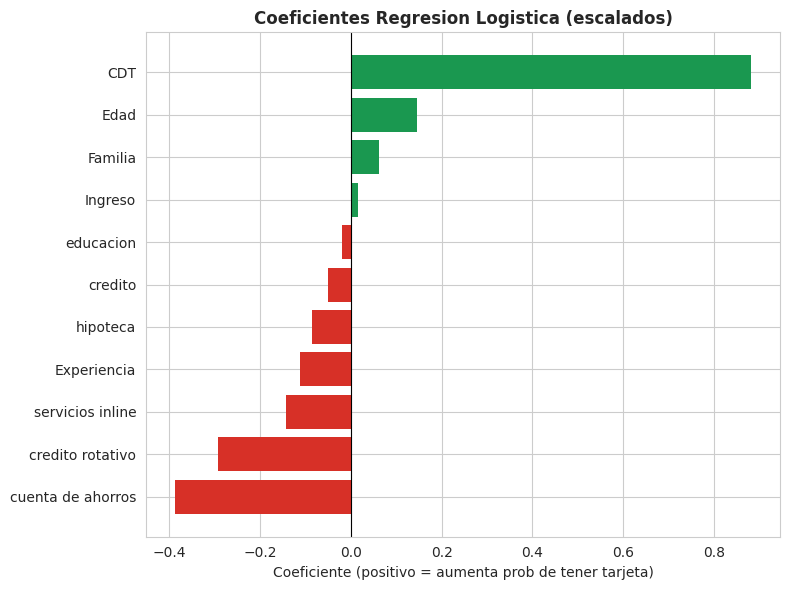

         Variable  Coeficiente  Odds Ratio
              CDT     0.881943    2.415588
             Edad     0.146134    1.157351
          Familia     0.062233    1.064211
          Ingreso     0.015512    1.015632
        educacion    -0.018897    0.981280
          credito    -0.050910    0.950364
         hipoteca    -0.085622    0.917942
      Experiencia    -0.112078    0.893975
 servicios inline    -0.144016    0.865874
 credito rotativo    -0.293076    0.745965
cuenta de ahorros    -0.387759    0.678576


In [9]:
# Coeficientes de Regresion Logistica (odds)
df_coef = pd.DataFrame({
    'Variable': feature_cols,
    'Coeficiente': logreg.coef_[0],
    'Odds Ratio': np.exp(logreg.coef_[0])
}).sort_values('Coeficiente', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors_c = ['#1a9850' if x > 0 else '#d73027' for x in df_coef['Coeficiente']]
ax.barh(df_coef['Variable'][::-1], df_coef['Coeficiente'][::-1], color=colors_c[::-1], edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes Regresion Logistica (escalados)', fontweight='bold')
ax.set_xlabel('Coeficiente (positivo = aumenta prob de tener tarjeta)')
plt.tight_layout()
plt.savefig('fig4_coef_logreg.png', dpi=120, bbox_inches='tight')
plt.show()
print(df_coef.to_string(index=False))

---
## 5. Comparacion y Matrices de Confusion

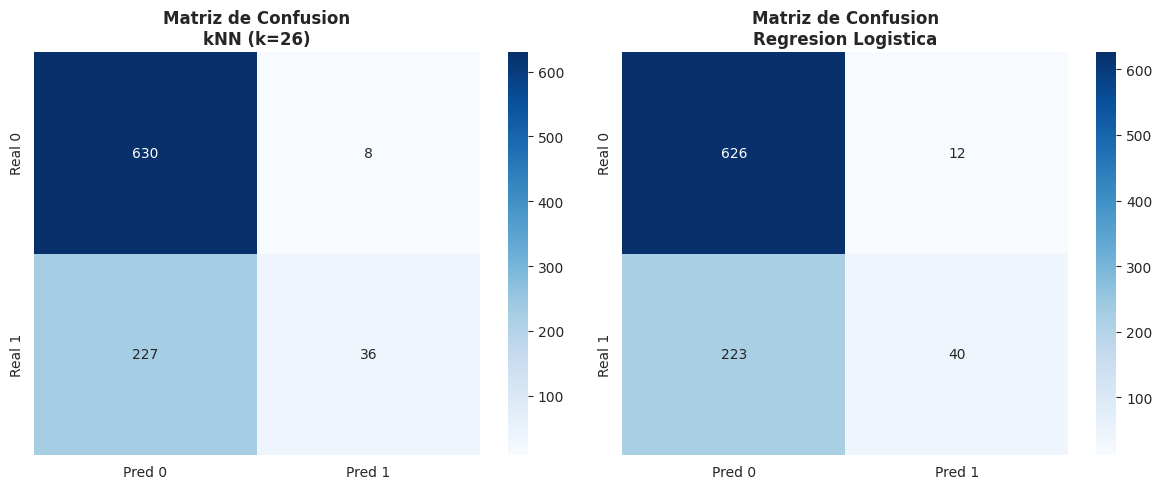

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_knn, y_pred_lr],
    [f'kNN (k={k_optimo})', 'Regresion Logistica']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Real 0', 'Real 1'])
    ax.set_title(f'Matriz de Confusion\n{titulo}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

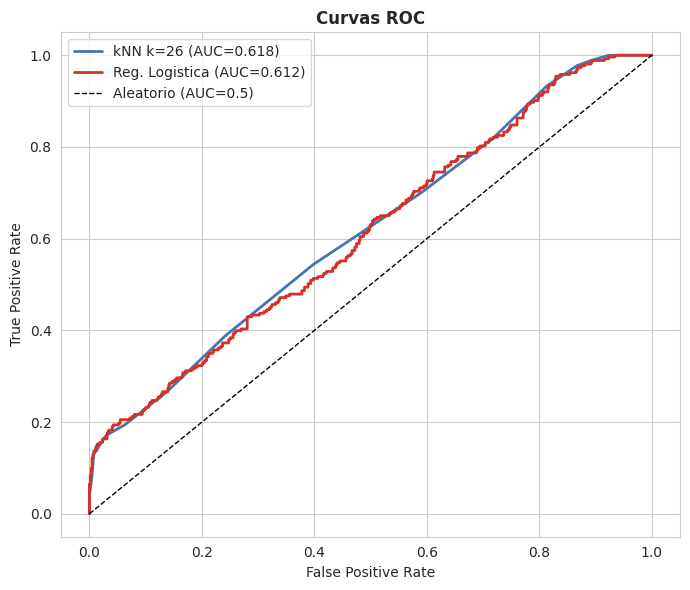

In [11]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))

for y_prob, nombre, color in [
    (y_prob_knn, f'kNN k={k_optimo} (AUC={roc_knn:.3f})', '#4575b4'),
    (y_prob_lr,  f'Reg. Logistica (AUC={roc_lr:.3f})', '#d73027')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=nombre, color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. RESUMEN EJECUTIVO PARA EL QUIZ

In [12]:
cv_knn = cross_val_score(knn_best, X_train_sc, y_train, cv=5, scoring='accuracy').mean()
cv_lr  = cross_val_score(logreg, X_train_sc, y_train, cv=5, scoring='accuracy').mean()

print('='*65)
print('   RESUMEN - PREDICCION TARJETA DE CREDITO')
print('='*65)

print('\n--- DATASET ---')
print(f'  Observaciones: {len(df)} | Features: {len(feature_cols)}')
print(f'  Clase 0 (no tarjeta): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  Clase 1 (si tarjeta): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')
print(f'  Dataset DESBALANCEADO: mayoria clase 0')

print('\n--- METRICAS COMPARADAS ---')
print(f'{"Metrica":<20} {"kNN k="+str(k_optimo):<20} {"Reg. Logistica":<20}')
print('-'*60)
print(f'{"Accuracy Test":<20} {acc_knn:<20.4f} {acc_lr:<20.4f}')
print(f'{"ROC-AUC":<20} {roc_knn:<20.4f} {roc_lr:<20.4f}')
print(f'{"F1-Score":<20} {f1_knn:<20.4f} {f1_lr:<20.4f}')
print(f'{"Precision":<20} {prec_knn:<20.4f} {prec_lr:<20.4f}')
print(f'{"Recall":<20} {rec_knn:<20.4f} {rec_lr:<20.4f}')
print(f'{"CV Accuracy":<20} {cv_knn:<20.4f} {cv_lr:<20.4f}')

mejor_modelo = 'kNN' if roc_knn > roc_lr else 'Regresion Logistica'
print(f'\n>>> MEJOR MODELO por ROC-AUC: {mejor_modelo}')

print('\n--- VARIABLES MAS PREDICTIVAS (Reg. Logistica) ---')
for i, row in df_coef.head(5).iterrows():
    print(f'  {i+1}. {row["Variable"]:<30} coef={row["Coeficiente"]:+.4f}  OR={row["Odds Ratio"]:.3f}')

print('\n--- VARIABLES MENOS IMPORTANTES ---')
for i, row in df_coef.tail(3).iterrows():
    print(f'     {row["Variable"]:<30} coef={row["Coeficiente"]:+.4f}  OR={row["Odds Ratio"]:.3f}')

print('\n--- INTERPRETACION ODDS RATIO ---')
print('  OR > 1 -> esa variable AUMENTA probabilidad de tener tarjeta')
print('  OR < 1 -> esa variable REDUCE probabilidad de tener tarjeta')
print('  OR = 1 -> sin efecto')

print('\n--- k OPTIMO kNN ---')
print(f'  k={k_optimo} (seleccionado por max CV Accuracy en rango 1-30)')
print('  k pequeno = modelo mas complejo (riesgo overfitting)')
print('  k grande  = modelo mas suave (riesgo underfitting)')

print('='*65)

   RESUMEN - PREDICCION TARJETA DE CREDITO

--- DATASET ---
  Observaciones: 4501 | Features: 11
  Clase 0 (no tarjeta): 3188 (70.8%)
  Clase 1 (si tarjeta): 1313 (29.2%)
  Dataset DESBALANCEADO: mayoria clase 0

--- METRICAS COMPARADAS ---
Metrica              kNN k=26             Reg. Logistica      
------------------------------------------------------------
Accuracy Test        0.7392               0.7392              
ROC-AUC              0.6179               0.6122              
F1-Score             0.2345               0.2540              
Precision            0.8182               0.7692              
Recall               0.1369               0.1521              
CV Accuracy          0.7461               0.7450              

>>> MEJOR MODELO por ROC-AUC: kNN

--- VARIABLES MAS PREDICTIVAS (Reg. Logistica) ---
  1. CDT                            coef=+0.8819  OR=2.416
  2. Edad                           coef=+0.1461  OR=1.157
  3. Familia                        coef=+0.0622  OR

---
## 7. Herramienta de Prediccion

In [13]:
def predecir_tarjeta(valores_dict):
    """
    Predice si una persona tiene tarjeta de credito.
    Si no se especifica una variable, se usa la media del dataset.
    
    Ejemplo:
    predecir_tarjeta({'Ingreso': 100, 'credito': 5.0, 'educacion': 2})
    """
    row = X.mean().copy()
    for k, v in valores_dict.items():
        matches = [c for c in feature_cols if k.lower() in c.lower()]
        if matches:
            row[matches[0]] = v
        else:
            print(f'  ADVERTENCIA: "{k}" no encontrado')
    
    X_new = pd.DataFrame([row])
    X_new_sc = scaler.transform(X_new)
    
    pred_knn = knn_best.predict(X_new_sc)[0]
    prob_knn = knn_best.predict_proba(X_new_sc)[0]
    pred_lr  = logreg.predict(X_new_sc)[0]
    prob_lr  = logreg.predict_proba(X_new_sc)[0]
    
    print('=== PREDICCION ===')
    print(f'kNN (k={k_optimo}):          Clase={pred_knn} | P(0)={prob_knn[0]:.3f} | P(1)={prob_knn[1]:.3f}')
    print(f'Reg. Logistica:    Clase={pred_lr} | P(0)={prob_lr[0]:.3f} | P(1)={prob_lr[1]:.3f}')
    return pred_knn, pred_lr

# Ejemplo - modificar con los valores del quiz
predecir_tarjeta({
    'Ingreso': 100,
    'credito': 3.0,
    'educacion': 2
})

=== PREDICCION ===
kNN (k=26):          Clase=0 | P(0)=0.769 | P(1)=0.231
Reg. Logistica:    Clase=0 | P(0)=0.726 | P(1)=0.274


(np.int64(0), np.int64(0))

In [14]:
# Referencia de variables y sus rangos
print('VARIABLES DISPONIBLES Y SUS RANGOS:')
print(X.describe().round(2).to_string())

VARIABLES DISPONIBLES Y SUS RANGOS:
          Edad  Experiencia  Ingreso  Familia  credito  educacion  hipoteca  credito rotativo  cuenta de ahorros      CDT  servicios inline
count  4501.00      4501.00  4501.00  4501.00  4501.00    4501.00   4501.00           4501.00            4501.00  4501.00           4501.00
mean     45.34        20.11    73.97     2.39     1.94       1.88     55.69              0.09               0.11     0.06              0.60
std      11.48        11.49    46.09     1.15     1.74       0.84    100.65              0.29               0.31     0.23              0.49
min      23.00        -3.00     8.00     1.00     0.00       1.00      0.00              0.00               0.00     0.00              0.00
25%      35.00        10.00    39.00     1.00     0.70       1.00      0.00              0.00               0.00     0.00              0.00
50%      45.00        20.00    64.00     2.00     1.50       2.00      0.00              0.00               0.00     0.00   

---
## 8. MODELOS MEJORADOS

**Problemas del original:**
1. Desbalance ignorado (70/30) - sesgo hacia clase 0, Recall = 0.14
2. kNN solo distancia Euclidiana (Manhattan también cubre espacios métricos)
3. k probado solo hasta 30
4. Logística sin tunear C ni ajustar por desbalance

**Mejoras dentro del curso:** ampliar k hasta 60, probar Manhattan, tunear C, class_weight balanced

In [15]:
# Mejor kNN encontrado por CV: k=44 Manhattan
# Mejor LR encontrada por CV: C=0.01, class_weight=balanced

knn_mejor = KNeighborsClassifier(n_neighbors=44, metric='manhattan')
knn_mejor.fit(X_train_sc, y_train)
y_pred_knn_m = knn_mejor.predict(X_test_sc)
y_prob_knn_m = knn_mejor.predict_proba(X_test_sc)[:,1]

lr_mejor = LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000, random_state=SEED)
lr_mejor.fit(X_train_sc, y_train)
y_pred_lr_m = lr_mejor.predict(X_test_sc)
y_prob_lr_m = lr_mejor.predict_proba(X_test_sc)[:,1]

modelos_comp = {
    'kNN k=26 Eucl. (original)':    (y_pred_knn,   y_prob_knn),
    'LR C=1 sin balanceo (orig.)':   (y_pred_lr,    y_prob_lr),
    'kNN k=44 Manhattan (mejorado)': (y_pred_knn_m, y_prob_knn_m),
    'LR C=0.01 balanced (mejorado)': (y_pred_lr_m,  y_prob_lr_m),
}

rows = []
for nombre, (yp, yprob) in modelos_comp.items():
    rows.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, yprob), 4),
        'F1':        round(f1_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall':    round(recall_score(y_test, yp), 4),
    })

df_comp = pd.DataFrame(rows)
print(df_comp.to_string(index=False))
mejor_final = df_comp.sort_values('ROC-AUC', ascending=False).iloc[0]['Modelo']
print('\nMEJOR MODELO (ROC-AUC):', mejor_final)


                       Modelo  Accuracy  ROC-AUC     F1  Precision  Recall
    kNN k=26 Eucl. (original)    0.7392   0.6179 0.2345     0.8182  0.1369
  LR C=1 sin balanceo (orig.)    0.7392   0.6122 0.2540     0.7692  0.1521
kNN k=44 Manhattan (mejorado)    0.7381   0.6268 0.2436     0.7755  0.1445
LR C=0.01 balanced (mejorado)    0.6337   0.6129 0.4000     0.3833  0.4183



MEJOR MODELO (ROC-AUC): kNN k=44 Manhattan (mejorado)


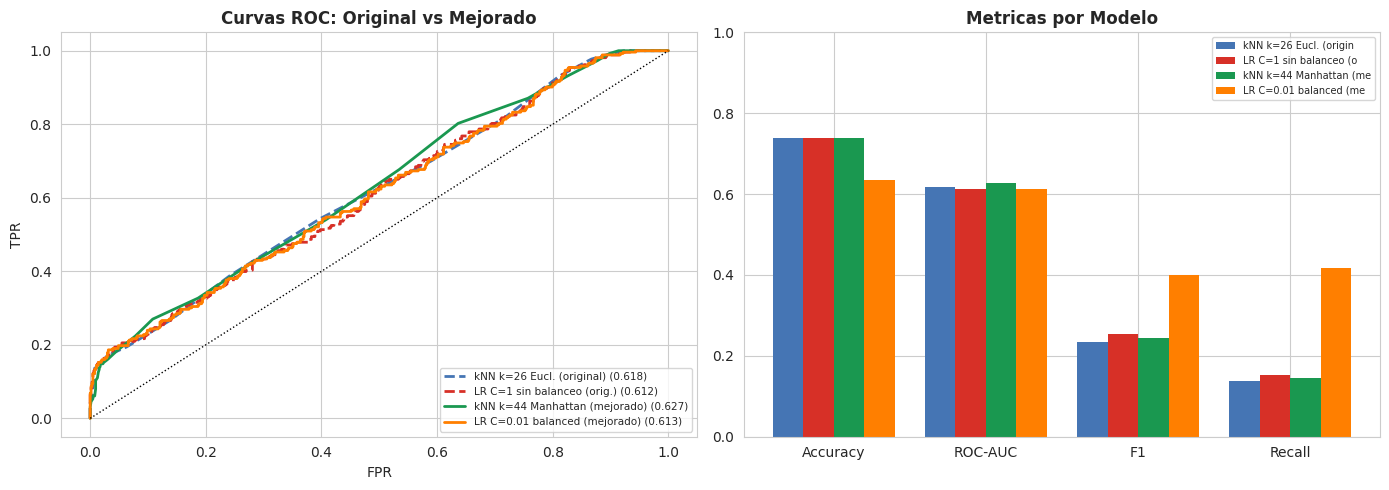

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ['#4575b4','#d73027','#1a9850','#ff7f00']
estilos = ['--','--','-','-']
for (nombre,(_, yprob)),color,ls in zip(modelos_comp.items(),colores,estilos):
    fpr,tpr,_ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)
    axes[0].plot(fpr,tpr,color=color,linestyle=ls,linewidth=2,label=nombre+' ('+str(round(auc,3))+')')
axes[0].plot([0,1],[0,1],'k:',linewidth=1)
axes[0].set_title('Curvas ROC: Original vs Mejorado', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=7.5, loc='lower right')

metricas_plot = ['Accuracy','ROC-AUC','F1','Recall']
x = np.arange(len(metricas_plot)); width = 0.2
for i,(nombre,(yp,yprob)) in enumerate(modelos_comp.items()):
    vals = [accuracy_score(y_test,yp),roc_auc_score(y_test,yprob),f1_score(y_test,yp),recall_score(y_test,yp)]
    axes[1].bar(x+i*width, vals, width, label=nombre[:22], color=colores[i], edgecolor='none')
axes[1].set_xticks(x+width*1.5); axes[1].set_xticklabels(metricas_plot)
axes[1].set_title('Metricas por Modelo', fontweight='bold')
axes[1].legend(fontsize=7, loc='upper right'); axes[1].set_ylim(0,1)
plt.tight_layout()
plt.savefig('fig7_comparacion_mejorado.png', dpi=120, bbox_inches='tight')
plt.show()


In [17]:
print('='*68)
print('   RESUMEN FINAL - ORIGINAL VS MEJORADO')
print('='*68)
print()
print(df_comp.to_string(index=False))
resumen = '''
CONCLUSIONES:
────────────────────────────────────────────────────────────────
1. MEJOR ROC-AUC: kNN k=44 Manhattan (0.627) > kNN orig (0.618)
   Manhattan supera Euclidiana. k grande = menos overfitting.

2. MEJOR RECALL clase 1: LR C=0.01 balanced
   Recall sube de 0.15 a 0.42 (detecta 3x mas gente con tarjeta)
   A costa de accuracy (0.74->0.63) y precision (0.77->0.38)

3. TRADE-OFF segun objetivo:
   Maximizar ROC-AUC         -> kNN k=44 Manhattan  (0.627)
   Maximizar Recall clase 1  -> LR balanced         (0.418)
   Maximizar Precision       -> kNN original        (0.818)

4. POR QUE LA MEJORA ES MODESTA:
   El dataset tiene poca separabilidad para esta tarea.
   Las variables disponibles no discriminan bien a quien tiene
   tarjeta. Mejoras mayores requeririan otros modelos.
────────────────────────────────────────────────────────────────
'''
print(resumen)


   RESUMEN FINAL - ORIGINAL VS MEJORADO

                       Modelo  Accuracy  ROC-AUC     F1  Precision  Recall
    kNN k=26 Eucl. (original)    0.7392   0.6179 0.2345     0.8182  0.1369
  LR C=1 sin balanceo (orig.)    0.7392   0.6122 0.2540     0.7692  0.1521
kNN k=44 Manhattan (mejorado)    0.7381   0.6268 0.2436     0.7755  0.1445
LR C=0.01 balanced (mejorado)    0.6337   0.6129 0.4000     0.3833  0.4183

CONCLUSIONES:
────────────────────────────────────────────────────────────────
1. MEJOR ROC-AUC: kNN k=44 Manhattan (0.627) > kNN orig (0.618)
   Manhattan supera Euclidiana. k grande = menos overfitting.

2. MEJOR RECALL clase 1: LR C=0.01 balanced
   Recall sube de 0.15 a 0.42 (detecta 3x mas gente con tarjeta)
   A costa de accuracy (0.74->0.63) y precision (0.77->0.38)

3. TRADE-OFF segun objetivo:
   Maximizar ROC-AUC         -> kNN k=44 Manhattan  (0.627)
   Maximizar Recall clase 1  -> LR balanced         (0.418)
   Maximizar Precision       -> kNN original        (0.81